# Heat Equation (Physics informed)

## Mapping sparse data $u(x,y, t=t_1,t_2,...)$ to the solution space (L-shaped)

$$ u_t-{\mathcal{K}}\left(u_{x x}+u_{y y}\right) =0, \quad t \in[0,1], x, y \in[-0.5,0.5]$$ 

$$ u_{\text{bc}} = 0$$

$$ \text{Data}: \mathcal{K} \sim \text{logspace}(0.01, 0.2) ~~ \& ~~ u_{\text{ic}} \sim \text{GRFs}$$ 

Number of samples: 100*100

In [1]:
from flax import linen as nn
from typing import Sequence, Tuple
import jax
import jax.numpy as jnp
from torch.utils import data
from functools import partial
import time
import optax
import scipy.io
import os
import matplotlib.pyplot as plt
import shutil
import pandas as pd
from jax import jvp
import pickle
from sklearn import metrics
from termcolor import colored
import random
import numpy as np
from scipy.interpolate import griddata
import matplotlib.tri as tri
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator, ScalarFormatter

In [2]:
## All inputs

path_data = '/home/droysar1/scr4_sgoswam4/Dibakar/Diffusion_project/L_shape_data/L_shape_heat_eqn_K_sweep3'

seed = 32
n_train = 8000
batch_size = 2500
n_sensors = 40*11 # (x*y, t)
branch_layers = [32, 32, 32]
branch_input_features = 1
trunk_layers = [32, 32, 32]
trunk_input_features = 3
hidden_dim = 70
p_test = 100
result_dir = './'
epochs = 80000
vis_iter = 1000
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9


In [3]:
# Data loading

sensor_data = jnp.array(jnp.load(os.path.join(path_data, 'sensor_data.npy')))
sensor_positions = jnp.array(jnp.load(os.path.join(path_data, 'sensor_positions.npy')))
sensor_times = jnp.array(jnp.load(os.path.join(path_data, 'sensor_times.npy')))

full_solution = jnp.array(jnp.load(os.path.join(path_data, 'output_data.npy')))
full_solution_mesh = jnp.array(jnp.load(os.path.join(path_data, 'mesh_points.npy')))
time_steps = jnp.array(jnp.load(os.path.join(path_data, 'time_steps.npy')))

initial_con = jnp.array(jnp.load(os.path.join(path_data, 'input_data.npy')))

k_all = jnp.array(jnp.load(os.path.join(path_data, 'ks.npy')))


print("sensor_data: ", str(sensor_data.shape))
print("sensor_positions: ", str(sensor_positions.shape))
print("sensor_times: ", str(sensor_times.shape))
print("full_solution: ", str(full_solution.shape))
print("full_solution_mesh: ", str(full_solution_mesh.shape))
print("time_steps: ", str(time_steps.shape))
print("initial_con: ", str(initial_con.shape))
print("k_all: ", str(k_all.shape))



samples, sensors, timepoints = sensor_data.shape
reshaped_sensor_data = sensor_data.transpose(0, 2, 1).reshape(samples, sensors * timepoints)
positions_tiled = np.tile(sensor_positions, (len(sensor_times), 1))
times_repeated = np.repeat(sensor_times, len(sensor_positions)).reshape(-1, 1)
sensor_coordinates = np.hstack((positions_tiled, times_repeated))

#----- Reshaped --------#
print("#----- Reshaped --------#")
print("reshaped_sensor_data: ", str(reshaped_sensor_data.shape))
print("sensor_coordinates: ", str(sensor_coordinates.shape))

samples, sensors, timepoints = full_solution.shape
reshaped_solution_data = full_solution.transpose(0, 2, 1).reshape(samples, sensors * timepoints)
full_solution_mesh_tiled = np.tile(full_solution_mesh, (len(time_steps), 1))
times_repeated = np.repeat(time_steps, len(full_solution_mesh)).reshape(-1, 1)
full_solution_coordinates = np.hstack((full_solution_mesh_tiled, times_repeated))

#----- Reshaped --------#
print("#----- Reshaped --------#")
print("reshaped_solution_data: ", str(reshaped_solution_data.shape))
print("full_solution_coordinates: ", str(full_solution_coordinates.shape))


2025-11-10 18:51:50.823758: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.68. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


sensor_data:  (10000, 40, 11)
sensor_positions:  (40, 2)
sensor_times:  (11,)
full_solution:  (10000, 833, 101)
full_solution_mesh:  (833, 2)
time_steps:  (101,)
initial_con:  (10000, 833)
k_all:  (10000,)
#----- Reshaped --------#
reshaped_sensor_data:  (10000, 440)
sensor_coordinates:  (440, 3)
#----- Reshaped --------#
reshaped_solution_data:  (10000, 84133)
full_solution_coordinates:  (84133, 3)


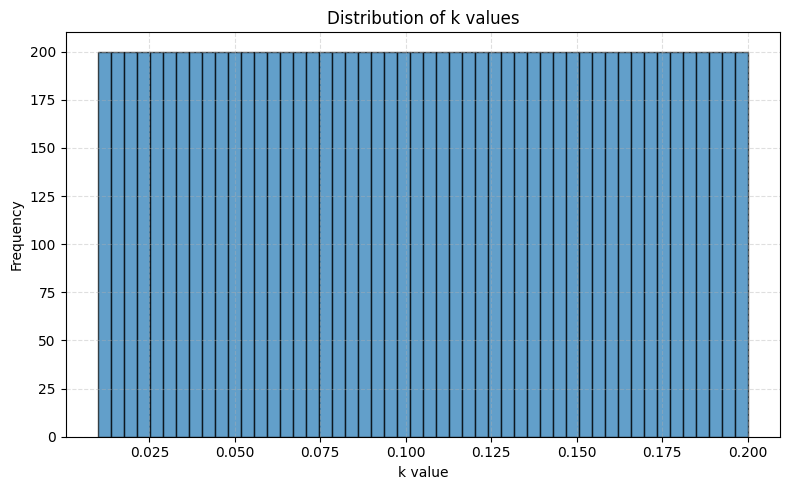

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming k_all is a NumPy array of shape (10000,)
def plot_k_distribution(k_all, bins=50):
    plt.figure(figsize=(8, 5))
    plt.hist(k_all, bins=bins, color='#1f77b4', edgecolor='black', alpha=0.7)
    plt.xlabel("k value")
    plt.ylabel("Frequency")
    plt.title("Distribution of k values")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    
plot_k_distribution(k_all)

In [5]:
# Shuffle the data
indices = np.arange(reshaped_sensor_data.shape[0])
np.random.shuffle(indices)

shuffled_sensor_data = reshaped_sensor_data[indices]
shuffled_solution_data = reshaped_solution_data[indices]
shuffled_k_data = k_all[indices]
shuffled_initial_con = initial_con[indices]

# Split
X_train = shuffled_sensor_data[:n_train]
X_test = shuffled_sensor_data[n_train:]

y_train = shuffled_sensor_data[:n_train]
y_test = shuffled_solution_data[n_train:]

k_train = shuffled_k_data[:n_train]
k_test = shuffled_k_data[n_train:]

initial_con_train = shuffled_initial_con[:n_train]
initial_con_test = shuffled_initial_con[n_train:]

print("X_train: ", str(X_train.shape))
print("X_test: ", str(X_test.shape))

print("y_train: ", str(y_train.shape))
print("y_test: ", str(y_test.shape))

print("k_train: ", str(k_train.shape))
print("k_test: ", str(k_test.shape))

print("initial_con_train: ", str(initial_con_train.shape))
print("initial_con_test: ", str(initial_con_test.shape))

X_train:  (8000, 440)
X_test:  (2000, 440)
y_train:  (8000, 440)
y_test:  (2000, 84133)
k_train:  (8000,)
k_test:  (2000,)
initial_con_train:  (8000, 833)
initial_con_test:  (2000, 833)


In [6]:
# Data Generator
class DataGenerator(data.Dataset):
    def __init__(self, u_data, y, s, k, batch_size, gen_key):
        self.u_data = u_data
        self.y = y
        self.s = s
        self.k = k
        self.N = u_data.shape[0]
        self.batch_size = batch_size
        self.key = gen_key

    def __getitem__(self, index):
        """Generate one batch of data"""
        self.key, subkey = jax.random.split(self.key)
        inputs, outputs = self.__data_generation(subkey)
        return inputs, outputs

    @partial(jax.jit, static_argnums=(0,))
    def __data_generation(self, key_i):
        """Generates data containing batch_size samples"""
        idx = jax.random.choice(key_i, self.N, (self.batch_size,), replace=False)
        s = self.s[idx, :]
        y = self.y[:, :]
        u_data = self.u_data[idx]
        k = self.k[idx]
        # Construct batch
        inputs = (u_data, y, k)
        outputs = s
        return inputs, outputs

In [7]:
"""# Data generation for each sample"""

key = jax.random.PRNGKey(seed)
keys = jax.random.split(key, 6)


data_dataset = DataGenerator(X_train, sensor_coordinates, y_train, k_train, batch_size, keys[0])




In [8]:
class DeepONet(nn.Module):
    branch_layers: Sequence[int]
    trunk_layers: Sequence[int]
    output_dim: int = 1

    @nn.compact
    def __call__(self, branch_x, trunk_x):

        init = nn.initializers.glorot_normal()

        if branch_x.ndim == 1:
            branch_x = jnp.expand_dims(branch_x, axis=-1)

        for i, fs in enumerate(self.branch_layers[:-1]):
            branch_x = nn.Dense(fs, kernel_init=init, name=f"branch_{i}")(branch_x)
            branch_x = nn.activation.tanh(branch_x)
        branch_x = nn.Dense(self.branch_layers[-1], name=f"branch_{i+1}", kernel_init=init)(branch_x)

        if trunk_x.ndim == 1:
            trunk_x = jnp.expand_dims(trunk_x, axis=0)


        for i, fs in enumerate(self.trunk_layers):
            trunk_x = nn.Dense(fs, kernel_init=init, name=f"trunk_{i}")(trunk_x)
            trunk_x = nn.activation.tanh(trunk_x)


         # [x_num, p]

        # Compute the final output
        # Input shapes:
        # branch: [batch_size, p]
        # trunk: [x_num, p]
        # output: [batch_size, x_num]
        result = jnp.einsum('ij,kj->ik', branch_x, trunk_x)

        # Add bias
        bias = self.param('output_bias', nn.initializers.zeros, (self.output_dim,))
        result += bias

        return result

In [9]:
"""# Helper functions"""

@partial(jax.jit)
def mse(y_true, y_pred):
    return jnp.mean(jnp.square(y_true - y_pred))

@partial(jax.jit)
def mse_single(y_pred):
    return jnp.mean(jnp.square(y_pred))

@partial(jax.jit, static_argnums=(0,))
def apply_net(model_fn, params, branch_input, *trunk_in):
    if len(trunk_in) == 1:
        trunk_input = trunk_in[0]
    else:
        trunk_input = jnp.stack(trunk_in, axis=-1)
    out = model_fn(params, branch_input, trunk_input)

    # Reshape to vector for single output for easier gradient computation
    # TODO: Adapt / Check squeeze
    if out.shape[1]==1:
        out = jnp.squeeze(out, axis=1)
    return out


@partial(jax.jit, static_argnums=(0, 1, 2))
def step(optimizer, loss_fn, model_fn, opt_state, params_step, data_batch):
    loss, gradient = jax.value_and_grad(loss_fn, argnums=1)(model_fn, params_step, data_batch)
    updates, opt_state = optimizer.update(gradient, opt_state)
    params_step = optax.apply_updates(params_step, updates)

    return loss, params_step, opt_state

In [10]:
"""# Loss functions"""

def loss_data(model_fn, params, data_batch):

    inputs, outputs = data_batch
    u_data, cord, _ = inputs

    x = cord[:, 0]
    y = cord[:, 1]
    t = cord[:, 2]

    s_pred = apply_net(model_fn, params, u_data, x, y, t)

    loss = mse(outputs, s_pred)
    return loss

def loss_fn(model_fn, params, data_batch):
    loss_data_i = loss_data(model_fn, params, data_batch)
    loss_value = loss_data_i
    return loss_value

In [11]:
"""# Initialize the model"""

# Initialize model and params
# make sure trunk_layers and branch_layers are lists
trunk_layers = [trunk_layers] if isinstance(trunk_layers, int) else trunk_layers

branch_layers = [branch_layers] if isinstance(branch_layers, int) else branch_layers

# add output features to trunk and branch layers
trunk_layers = trunk_layers + [hidden_dim]
branch_layers = branch_layers + [hidden_dim]

# Convert list to tuples
trunk_layers = tuple(trunk_layers)
branch_layers = tuple(branch_layers)

num_outputs = 1
model = DeepONet(branch_layers, trunk_layers, num_outputs)

params = model.init(key, jnp.ones(shape=(1, n_sensors * branch_input_features)),
                    jnp.ones(shape=(1, trunk_input_features)))

# Print model from parameters
print('--- model_summary ---')
# count total params
total_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f'total params: {total_params}')
print('--- model_summary ---')

# model function
model_fn = jax.jit(model.apply)


2025-11-10 18:51:54.599563: E external/xla/xla/service/hlo_lexer.cc:438] Failed to parse int literal: 894515288310727292233


--- model_summary ---
total params: 23085
--- model_summary ---


In [12]:
"""# Test error function"""

def loss_test_l2_error(model_fn, params, X_test, y_test, full_solution_coordinates, return_data=False):

    x = full_solution_coordinates[:,0]
    y = full_solution_coordinates[:,1]
    t = full_solution_coordinates[:,2]

    def ff_net(x, y, t):
        s_pred = apply_net(model_fn, params, X_test, x, y, t)
        return s_pred

    s_pred = ff_net(x, y, t)

    loss_test = mse(y_test, s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

    l2_error = jnp.mean(jax.vmap(l2_norm_error)(y_test, s_pred))

    if return_data:
        return loss_test, l2_error, s_pred
    else:
        return loss_test, l2_error

In [13]:
"""# Define optimiser"""

# Define optimizer with optax (ADAM)
# optimizer

lr_scheduler = optax.exponential_decay(lr, transition_steps, decay_rate)

optimizer = optax.adam(learning_rate=lr_scheduler)
opt_state = optimizer.init(params)

# Data
data_data = iter(data_dataset)

# create dir for saving results
result_dir = os.path.join(os.getcwd(), os.path.join(result_dir, f"solution_op2_{seed}"))
log_file = os.path.join(result_dir, 'log.csv')
# Create directory
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
if os.path.exists(os.path.join(result_dir, 'vis')):
    shutil.rmtree(os.path.join(result_dir, 'vis'))
if os.path.exists(log_file):
    os.remove(log_file)


with open(log_file, 'a') as f:
    f.write('epoch,loss,loss_data_value,l2err_test,loss_test,runtime\n')

In [14]:
"""# model save function"""

def save_model_params(params, result_dir, filename='model_params.pkl'):
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)

    save_path = os.path.join(result_dir, filename)
    with open(save_path, 'wb') as f:
        pickle.dump(params, f)

def load_model_params(result_dir, filename='model_params_best.pkl'):
    load_path = os.path.join(result_dir, filename)
    with open(load_path, 'rb') as f:
        params = pickle.load(f)
    return params

# Usage:
save = True
# Saving
if save:
    save_model_params(params, result_dir)

In [15]:
"""# Training loop"""

# Iterations
epochs = epochs  # Assuming 'epochs' is defined elsewhere
log_iter = 1000
best_test_mse = float('inf')  # Initialize with infinity
# Save initial model at 0th iteration
save_model_params(params, result_dir, filename='model_params_best.pkl')
print("Saved initial model at iteration 0")
# Training loop
for it in range(epochs):
    if it == 1:
        # start timer and exclude first iteration (compile time)
        start = time.time()
    # Fetch data
    data_batch = next(data_data)
    
    # Do Step
    loss, params, opt_state = step(optimizer, loss_fn, model_fn, opt_state,
                                   params, data_batch)
    if it % log_iter == 0:
        # Compute losses
        loss = loss_fn(model_fn, params, data_batch)
        loss_data_value = loss_data(model_fn, params, data_batch)
        
        # Calculate loss and l2 error for test samples
        loss_test, l2_error = loss_test_l2_error(model_fn, params, X_test, y_test, full_solution_coordinates, return_data=False)

        if loss_test < best_test_mse:
            best_test_mse = loss_test
            # Save the model as it's the best so far
            save_model_params(params, result_dir, filename='model_params_best.pkl')
            print(f"New best model saved at iteration {it} with test MSE: {loss_test:.2e}")

        # get runtime
        if it == 0:
            runtime = 0
        else:
            runtime = time.time() - start

        # Print losses
        print(f"Iteration {it+1}/{epochs}")
        print(f"Trian_loss: {loss:.2e}, "
              f"loss_data: {loss_data_value:.2e}, l2_err_test: {l2_error:.2e}, test_loss: {loss_test:.2e} , runtime: {runtime:06.2f}")

        # Save results
        with open(log_file, 'a') as f:
            f.write(f'{it+1}, {loss}, '
                    f'{loss_data_value}, {l2_error}, {loss_test}, {runtime}\n')

# Save results
runtime = time.time() - start
# Save initial model at 0th iteration
save_model_params(params, result_dir, filename='model_params_last.pkl')
print("Saved model at end of training")
with open(log_file, 'a') as f:
    f.write(f'{it + 1}, {loss}, '
            f'{loss_data_value}, {l2_error}, {loss_test}, {runtime}\n')

Saved initial model at iteration 0
New best model saved at iteration 0 with test MSE: 3.31e-02
Iteration 1/80000
Trian_loss: 3.20e-02, loss_data: 3.20e-02, l2_err_test: 1.70e+00, test_loss: 3.31e-02 , runtime: 000.00
New best model saved at iteration 1000 with test MSE: 1.48e-02
Iteration 1001/80000
Trian_loss: 7.12e-03, loss_data: 7.12e-03, l2_err_test: 1.25e+00, test_loss: 1.48e-02 , runtime: 000.80
Iteration 2001/80000
Trian_loss: 4.26e-03, loss_data: 4.26e-03, l2_err_test: 1.62e+00, test_loss: 2.60e-02 , runtime: 001.58
Iteration 3001/80000
Trian_loss: 2.79e-03, loss_data: 2.79e-03, l2_err_test: 1.91e+00, test_loss: 3.37e-02 , runtime: 002.36
Iteration 4001/80000
Trian_loss: 1.94e-03, loss_data: 1.94e-03, l2_err_test: 2.22e+00, test_loss: 4.51e-02 , runtime: 003.14
Iteration 5001/80000
Trian_loss: 1.43e-03, loss_data: 1.43e-03, l2_err_test: 2.43e+00, test_loss: 5.40e-02 , runtime: 003.93
Iteration 6001/80000
Trian_loss: 1.12e-03, loss_data: 1.12e-03, l2_err_test: 2.46e+00, test_los

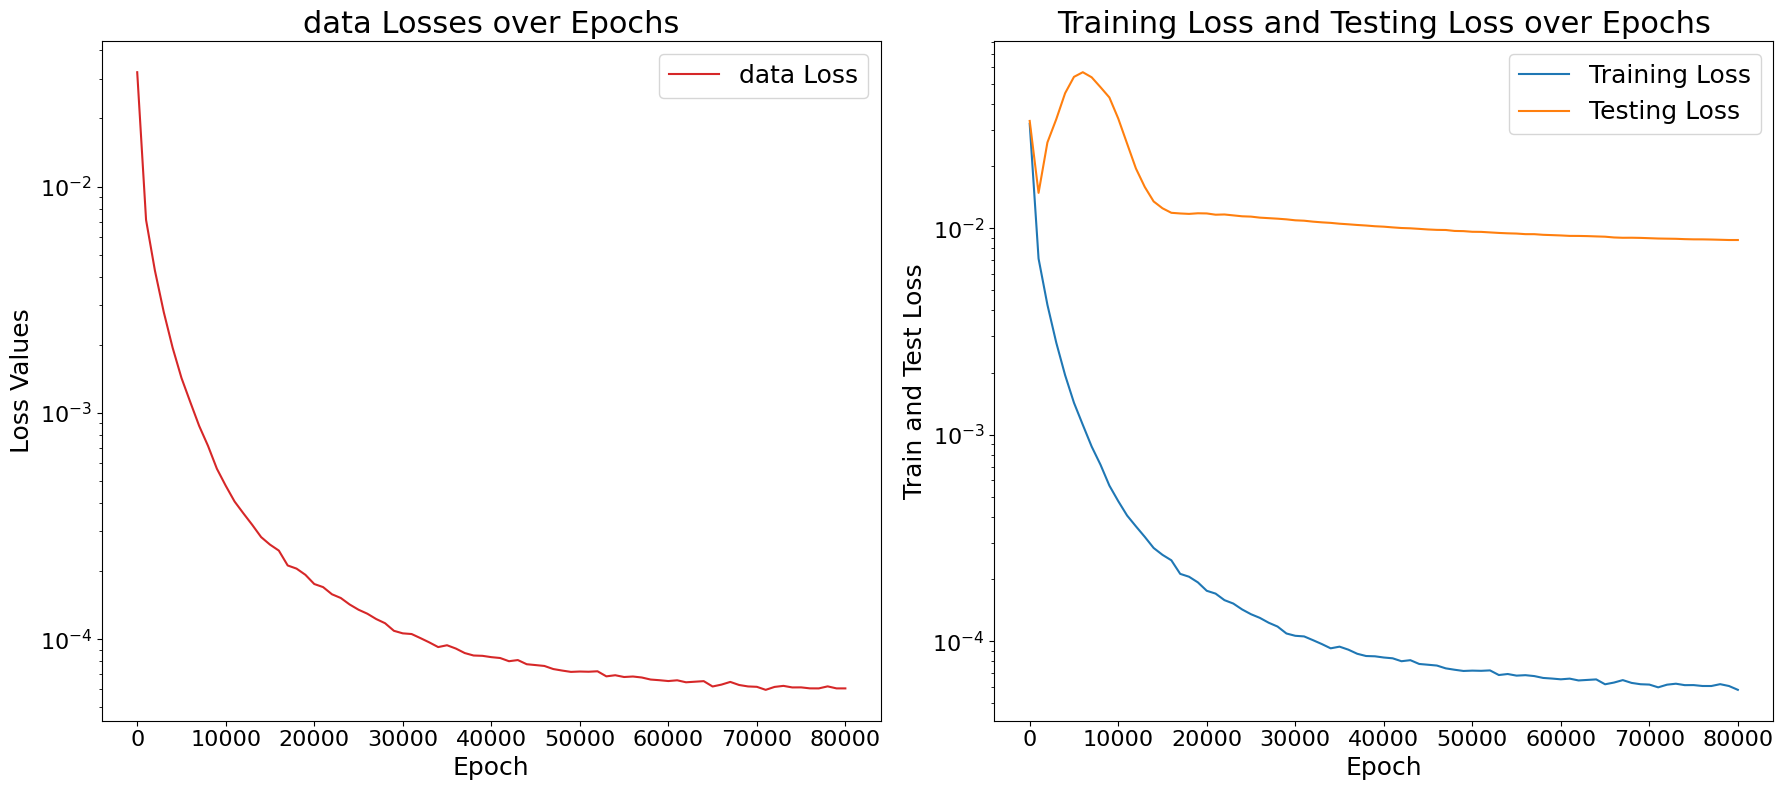

Plots saved to /scratch4/sgoswam4/Dibakar/INV_DON/2D_heat_L_dist/./solution_op2_32/train_and_test_loss_plots.png


In [16]:
"""# Loss plots"""

# Set the result directory

# Read the CSV file
csv_file = os.path.join(result_dir, "log.csv")  # Assuming the file is named "log.csv"
df = pd.read_csv(csv_file)

# Create the figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), dpi=100)

# Set color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Left plot: epoch vs loss_
ax1.plot(df['epoch'], df['loss_data_value'], label='data Loss', color=colors[3], linestyle='-')
ax1.set_yscale("log")
ax1.set_xlabel('Epoch', fontsize=18)
ax1.set_ylabel('Loss Values', fontsize=18)
ax1.set_title('data Losses over Epochs', fontsize=22)
ax1.legend(loc='best', fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Right plot: epoch vs loss and l2err_val
ax2.plot(df['epoch'], df['loss'], label='Training Loss', color=colors[0], linestyle='-')
ax2.plot(df['epoch'], df['loss_test'], label='Testing Loss', color=colors[1], linestyle='-')
ax2.set_yscale("log")
ax2.set_xlabel('Epoch', fontsize=18)
ax2.set_ylabel('Train and Test Loss', fontsize=18)
ax2.set_title('Training Loss and Testing Loss over Epochs', fontsize=22)
ax2.legend(loc='best', fontsize=18)
ax2.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Adjust layout and save the figure
plt.tight_layout()
output_file = os.path.join(result_dir, "train_and_test_loss_plots.png")
plt.savefig(output_file, dpi=100)
plt.show()
plt.close()

print(f"Plots saved to {output_file}")

In [17]:
params = load_model_params(result_dir)

loss_test, l2_error, s_pred = loss_test_l2_error(model_fn, params, X_test, y_test, full_solution_coordinates, return_data=True)

In [19]:
s_pred.shape

(2000, 84133)

/tmp/ipykernel_927293/3489746406.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


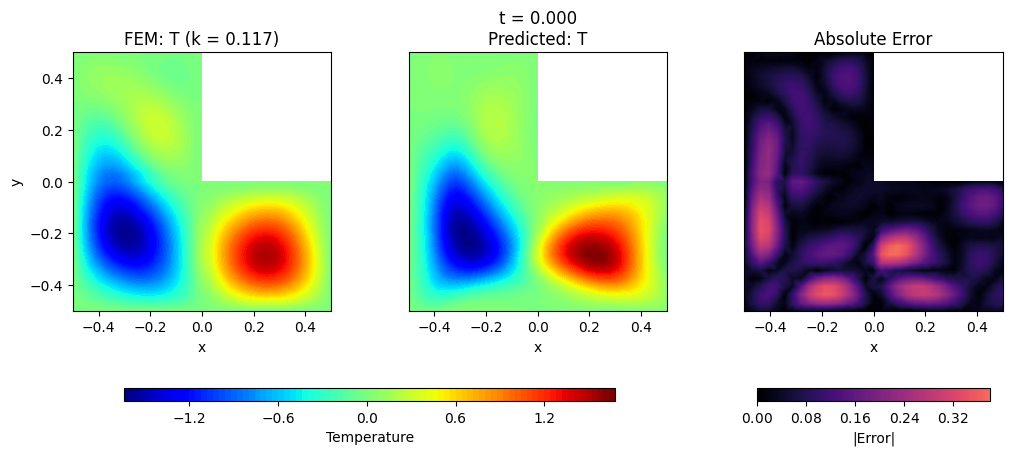

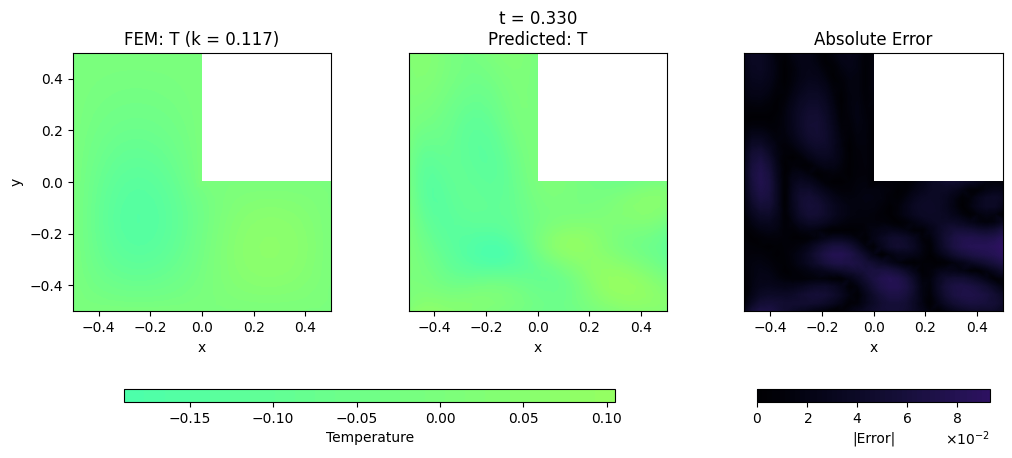

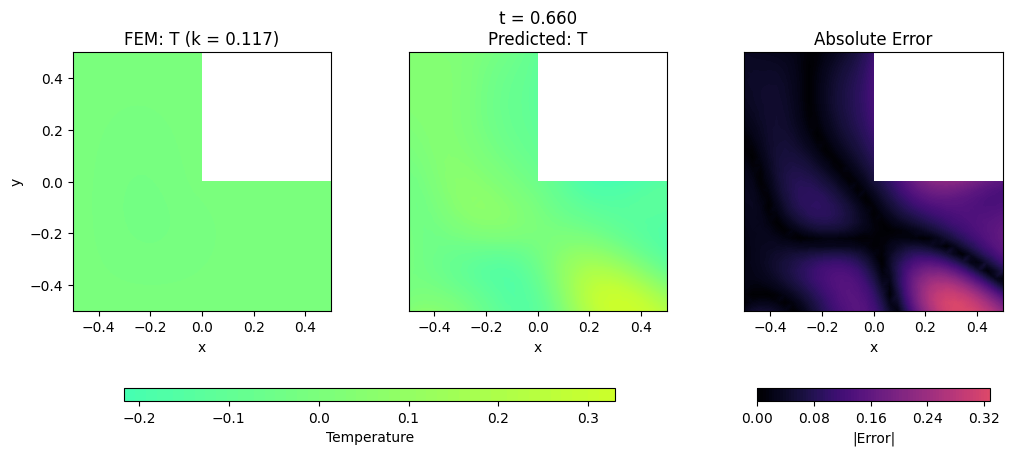

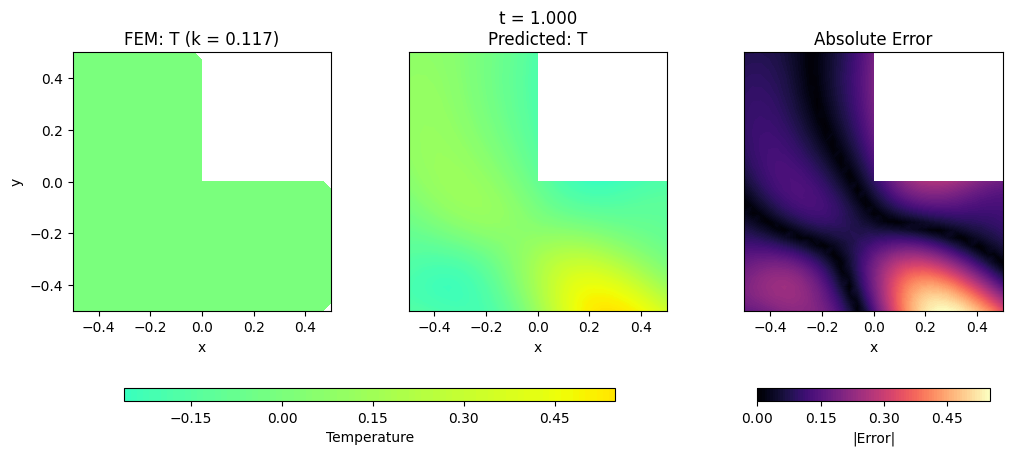

In [20]:
def get_masked_lshape_triangulation(x, y):
    triang = tri.Triangulation(x, y)
    xmid = x[triang.triangles].mean(axis=1)
    ymid = y[triang.triangles].mean(axis=1)
    mask = np.logical_or(xmid < 0, ymid < 0)
    triang.set_mask(~mask)
    return triang

sample_idx = 235
x = full_solution_coordinates[:, 0]
y = full_solution_coordinates[:, 1]
t = full_solution_coordinates[:, 2]

k_val = k_test[sample_idx]

pred = s_pred[sample_idx]
gt = y_test[sample_idx]
error = np.abs(pred - gt)

vmin = min(pred.min(), gt.min())
vmax = max(pred.max(), gt.max())
err_min = error.min()
err_max = error.max()

unique_times = np.unique(t)
n_plot = min(4, len(unique_times))
plot_times = unique_times[np.linspace(0, len(unique_times)-1, n_plot, dtype=int)]

for i, time_val in enumerate(plot_times):
    mask = t == time_val

    x_t, y_t = x[mask], y[mask]
    gt_t = gt[mask]
    pred_t = pred[mask]
    err_t = error[mask]

    triang = get_masked_lshape_triangulation(x_t, y_t)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.3})

    # FEM
    cont_gt = axes[0].tricontourf(triang, gt_t, cmap='jet', vmin=vmin, vmax=vmax, levels=100)
    # axes[0].set_title("FEM: T", fontsize=12)
    axes[0].set_title(f"FEM: T (k = {k_val:.3f})", fontsize=12)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect('equal')

    # Prediction
    cont_pred = axes[1].tricontourf(triang, pred_t, cmap='jet', vmin=vmin, vmax=vmax, levels=100)
    axes[1].set_title(f"t = {time_val:.3f}\nPredicted: T", fontsize=12)
    axes[1].set_xlabel("x")
    axes[1].set_yticks([])
    axes[1].set_aspect('equal')

    # Error
    cont_err = axes[2].tricontourf(triang, err_t, cmap='magma', vmin=err_min, vmax=err_max, levels=100)
    axes[2].set_title("Absolute Error", fontsize=12)
    axes[2].set_xlabel("x")
    axes[2].set_yticks([])
    axes[2].set_aspect('equal')

    # Temperature colorbar below FEM + Predicted
    cax_temp = inset_axes(axes[1], width="190%", height="5%", loc='lower center',
                          bbox_to_anchor=(-0.65, -0.35, 1, 1),
                          bbox_transform=axes[1].transAxes, borderpad=0)
    cbar1 = fig.colorbar(cont_pred, cax=cax_temp, orientation='horizontal')
    cbar1.set_label("Temperature", fontsize=10)
    cbar1.locator = MaxNLocator(nbins=6)
    cbar1.update_ticks()

    # Error colorbar below Absolute Error
    cax_err = inset_axes(axes[2], width="90%", height="5%", loc='lower center',
                         bbox_to_anchor=(0, -0.35, 1, 1),
                         bbox_transform=axes[2].transAxes, borderpad=0)
    cbar2 = fig.colorbar(cont_err, cax=cax_err, orientation='horizontal')
    cbar2.set_label("|Error|", fontsize=10)
    cbar2.locator = MaxNLocator(nbins=5)
    cbar2.formatter = ScalarFormatter(useMathText=True)
    cbar2.formatter.set_powerlimits((-2, 2))
    cbar2.update_ticks()

    plt.tight_layout()
    plt.show()